## Zero-shot Image Classification - I
##### classify zebra images without using any zebra images during training
*using image embedding & word embedding*


In zero-shot learning/classification, a model learns to classify classes it hasn’t seen during training. It is applicable in many scenarios where there is no or limited data.

A model, pre-trained on a set of classes (seen classes), is extended to novel classes (unseen classes) using auxiliary information (textual description, attributes, semantic information, or word embeddings). For example, a model trained to classify horse images can recognize zebras using textual descriptions of what animals look like: a zebra looks like a striped horse.

### Data
- Training, Validation, & Testing [Donkeys, Horses & Zebra Images Dataset](https://www.kaggle.com/datasets/ifeanyinneji/donkeys-horses-zebra-images-dataset) 
- Word Embeddings [Google News Word Vectors Dataset](https://www.kaggle.com/datasets/leadbest/googlenewsvectorsnegative300)

** There are only 60 zebra images in the test folder, therefore used the train folder zebra images for testing. 

### Approach

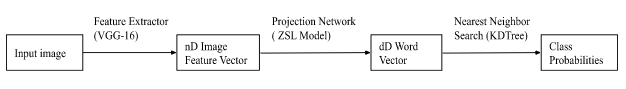

 - Embedding-based ZSL model
 - model input = 4096-dimensional image feature vector
 - model output = 300-dimensional word vector

In [1]:
# verbose = 2

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.applications import vgg16
from tensorflow.keras.layers import BatchNormalization, Dense, Dropout
from sklearn.preprocessing import normalize
from sklearn.neighbors import KDTree
from gensim.models import KeyedVectors

### Defining Classes

In [2]:
# seen/train & unseen/zsl classes
classes_train = ['horse', 'donkey']
classes_zsl = ['zebra']

### Data Preprocessing

In [3]:
# data paths
path_train = '../input/donkeys-horses-zebra-images-dataset/train'
path_zsl = '../input/donkeys-horses-zebra-images-dataset/train'
path_test_img = '../input/donkeys-horses-zebra-images-dataset/test/zebra/zebra (45).jpg'
path_word2vec = '../input/googlenewsvectorsnegative300/GoogleNews-vectors-negative300.bin'

In [4]:
# data generators
idg_train = image.ImageDataGenerator(rescale=1./255, validation_split=0.2,
                                    width_shift_range=0.1, height_shift_range=0.1,
                                    rotation_range=15, shear_range=0.1,
                                    zoom_range=0.2, horizontal_flip=False,
                                    fill_mode='nearest')  
idg_test = image.ImageDataGenerator(rescale=1./255)

data_train = idg_train.flow_from_directory(directory=path_train, 
                                           subset='training', 
                                           target_size=(224,224), batch_size=32, 
                                           shuffle=True, color_mode='rgb', 
                                           class_mode='categorical', 
                                           classes=classes_train)
data_valid = idg_train.flow_from_directory(directory=path_train,
                                           subset='validation', 
                                           target_size=(224,224), batch_size=32, 
                                           shuffle=True, color_mode='rgb', 
                                           class_mode='categorical', 
                                           classes=classes_train)
data_zsl = idg_test.flow_from_directory(directory=path_zsl, 
                                        target_size=(224,224), batch_size=1, 
                                        shuffle=False, color_mode='rgb', 
                                        class_mode='categorical', 
                                        classes=classes_zsl)

Found 628 images belonging to 2 classes.
Found 155 images belonging to 2 classes.
Found 226 images belonging to 1 classes.


In [5]:
# get number of batches 
batch_size = 32

if data_train.samples % batch_size:
    n_batches_train = data_train.samples // batch_size + 1
else:
    n_batches_train = data_train.samples // batch_size

if data_valid.samples % batch_size:
    n_batches_valid = data_valid.samples // batch_size + 1
else:
    n_batches_valid = data_valid.samples // batch_size

n_batches_test = data_zsl.samples     # bcz batch size is 1 in test generator

In [6]:
# extract labels from data generators

y_train = list()
for i in range(n_batches_train):  
    _, y_batch = next(data_train)     # next() returns x_batch, y_batch
    y_train.extend(y_batch)
y_train = np.array(y_train)

y_valid = list()
for i in range(n_batches_valid): 
    _, y_batch = next(data_valid)
    y_valid.extend(y_batch)
y_valid = np.array(y_valid)

y_zsl = list()
for i in range(n_batches_test):     
    _, y_batch = next(data_zsl)
    y_zsl.extend(y_batch)
y_zsl = np.array(y_zsl)

### Feature Extraction/Image Embedding

In [7]:
# load pretrained VGG16 for feature extraction
# input_shape = (height, width, channel)
model_vgg = vgg16.VGG16(input_shape=(224, 224, 3), weights='imagenet', 
                        include_top=True)  
model_vgg.summary()

553467096/553467096 [==============================] - 17s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                           

In [8]:
# remove last two layers to extract features (4096D)
model_fe = Model(name='feature_extractor', 
                 inputs=model_vgg.input, 
                 outputs=model_vgg.layers[-3].output)
model_fe.summary()

Model: "feature_extractor"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128) 

In [9]:
# extract features
x_train = model_fe.predict(data_train)
x_valid = model_fe.predict(data_valid)
x_zsl = model_fe.predict(data_zsl)

226/226 [==============================] - 53s 235ms/step


In [10]:
# normalize features
x_train = normalize(x_train, norm='l2')
x_valid = normalize(x_valid, norm='l2')
x_zsl = normalize(x_zsl, norm='l2')

### Class/Word Embedding

In [11]:
# get word/semantic vector (300D) using Word2vec pre-trained on google news
classes = classes_train + classes_zsl
model_word2vec = KeyedVectors.load_word2vec_format(fname=path_word2vec, 
                                                   binary=True)      
word_vec = list()
for word in classes:
    if word in model_word2vec.key_to_index:
        word_vec.append(model_word2vec[word])
    else:
        word_vec.append([0])
word_vec = np.asarray(word_vec, dtype=float)
word_vec

array([[ 5.34057617e-04,  3.11279297e-02,  5.03540039e-03,
        -9.17968750e-02, -8.36181641e-03, -1.66015625e-01,
         3.93066406e-02,  2.97851562e-02,  1.69921875e-01,
        -2.04101562e-01,  2.41210938e-01, -3.04687500e-01,
        -2.24609375e-02, -3.71093750e-01, -5.61523438e-02,
         1.51367188e-01, -1.21582031e-01,  3.41796875e-01,
         3.05175781e-02, -2.94921875e-01,  6.54296875e-02,
        -9.27734375e-02,  1.49414062e-01,  8.15429688e-02,
        -6.93359375e-02,  1.98242188e-01, -1.66015625e-01,
         2.00195312e-01,  1.16699219e-01, -3.69140625e-01,
        -2.48046875e-01,  1.25976562e-01,  3.59375000e-01,
         1.51367188e-01, -7.76367188e-02,  2.91015625e-01,
        -1.74560547e-02, -1.21093750e-01, -1.00097656e-01,
         1.43554688e-01,  5.92041016e-03,  2.35595703e-02,
         3.20312500e-01,  1.82617188e-01,  9.52148438e-02,
         9.22851562e-02,  8.30078125e-02, -1.33789062e-01,
         9.57031250e-02,  1.66992188e-01,  1.87988281e-0

In [12]:
# convert 1D zsl labels to 300D word vectors
y_zsl = np.array([word_vec[2] for _ in range(len(y_zsl))])

### Model Development & Training

In [13]:
model_zsl = Sequential(name='zsl')
model_zsl.add(Dense(units=1024, 
                    input_shape=(4096,),        # input_shape = x.shape
                    activation='relu'))
model_zsl.add(BatchNormalization())
model_zsl.add(Dropout(0.8))
model_zsl.add(Dense(512, activation='relu'))
model_zsl.add(Dropout(0.5))
model_zsl.add(Dense(300,                       # 300 units bcz word vector cols are 300
                    activation='relu'))  

In [14]:
# last layer weights → transpose of Word2Vecs of the training classes
# transpose is to match shape (input, otput). word vector is (2, 300) & model is (300, 2)

def custom_kernel_init(shape, dtype=None):
    return word_vec[:2].T


model_zsl.add(Dense(units=len(classes_train), activation='softmax', 
                    trainable=False, kernel_initializer=custom_kernel_init))     

In [15]:
# model summary
model_zsl.summary()

Model: "zsl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1024)              4195328   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 300)               153900    
                                                               

In [16]:
# train model
model_zsl.compile(optimizer='adam', 
                  loss='categorical_crossentropy', 
                  metrics=['categorical_accuracy', 'top_k_categorical_accuracy'])
hist = model_zsl.fit(x=x_train, y=y_train, 
                     validation_data=(x_valid, y_valid), 
                     verbose=2, epochs=65, shuffle=True)
hist

Epoch 1/65
20/20 - 2s - loss: 0.6755 - categorical_accuracy: 0.6035 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.6873 - val_categorical_accuracy: 0.4903 - val_top_k_categorical_accuracy: 1.0000 - 2s/epoch - 103ms/step
Epoch 2/65
20/20 - 1s - loss: 0.5916 - categorical_accuracy: 0.7118 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.6640 - val_categorical_accuracy: 0.8000 - val_top_k_categorical_accuracy: 1.0000 - 628ms/epoch - 31ms/step
Epoch 3/65
20/20 - 1s - loss: 0.5440 - categorical_accuracy: 0.7643 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.6708 - val_categorical_accuracy: 0.5548 - val_top_k_categorical_accuracy: 1.0000 - 619ms/epoch - 31ms/step
Epoch 4/65
20/20 - 1s - loss: 0.5097 - categorical_accuracy: 0.7803 - top_k_categorical_accuracy: 1.0000 - val_loss: 0.6533 - val_categorical_accuracy: 0.5484 - val_top_k_categorical_accuracy: 1.0000 - 644ms/epoch - 32ms/step
Epoch 5/65
20/20 - 1s - loss: 0.5123 - categorical_accuracy: 0.7659 - top_k_categorical_accuracy: 

In [17]:
# remove the last layer to get 300D word vector as output 
model_zsl.pop()
model_zsl.summary()

Model: "zsl"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1024)              4195328   
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                                   
                                                                 
 dropout (Dropout)           (None, 1024)              0         
                                                                 
 dense_1 (Dense)             (None, 512)               524800    
                                                                 
 dropout_1 (Dropout)         (None, 512)               0         
                                                                 
 dense_2 (Dense)             (None, 300)               153900    
                                                               

In [18]:
# save model
model_zsl.save('model_zsl_embedding.h5')

### Model Evaluation

In [19]:
# evaluation metrics (loss, categorical accuracy, top k categorical accuracy)
eval_metrics = model_zsl.evaluate(x=x_zsl, y=y_zsl, return_dict=True)
eval_metrics

8/8 [==============================] - 0s 9ms/step - loss: 4.1994 - categorical_accuracy: 0.0000e+00 - top_k_categorical_accuracy: 0.0000e+00


{'loss': 4.199398994445801,
 'categorical_accuracy': 0.0,
 'top_k_categorical_accuracy': 0.0}

In [20]:
# predict
y_zsl_pred = model_zsl.predict(x=x_zsl) 

8/8 [==============================] - 0s 9ms/step


In [21]:
# top-3, top-2 & top-1 accuracy 

tree = KDTree(word_vec)                      # place class vectors in KDTree     

top3, top2, top1 = 0, 0, 0
for pred in y_zsl_pred:
    pred = np.expand_dims(pred, axis=0)
    dist_3, index_3 = tree.query(pred, k=3)   # search for 3 neighbours
    if 2 in index_3[0]:                       # 2 = zebra index in classes list 
        top3 += 1
    if 2 in index_3[0][:2]: 
        top2 += 1
    if 2 == index_3[0][0]:
        top1 += 1
print('Top-3 Accuracy: {:.2f}%'.format(100 * top3 / len(y_zsl_pred)))
print('Top-2 Accuracy: {:.2f}%'.format(100 * top2 / len(y_zsl_pred)))
print('Top-1 Accuracy: {:.2f}%'.format(100 * top1 / len(y_zsl_pred)))

Top-3 Accuracy: 100.00%
Top-2 Accuracy: 97.35%
Top-1 Accuracy: 43.81%


### Testing Image

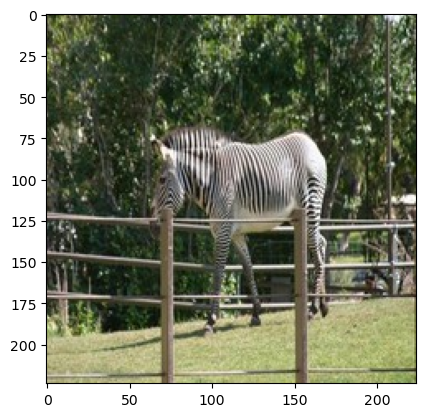

In [22]:
# load image
img = image.load_img(path_test_img, target_size=(224, 224))
plt.imshow(img)

In [23]:
# convert image to a 3D numpy array (height, width, channel)
# channel is 3 for RGB and 1 for grayscale images
img = image.img_to_array(img)

In [24]:
# normalize image
img /= 255.

In [25]:
# expand dims (3D -> 4D), to add batch size as 1
img = np.expand_dims(img, axis=0) 

In [26]:
# get image feature vector
img_vec = model_fe.predict(img)

1/1 [==============================] - 0s 353ms/step


In [27]:
# normalize features
img_vec = normalize(img_vec, norm='l2')

In [28]:
# get word vector for image
img_wordvec = model_zsl.predict(img_vec)

1/1 [==============================] - 0s 19ms/step


In [29]:
# search for 3 closest word2vec (neighbours)
dist, index_3 = tree.query(img_wordvec, k=3)

In [30]:
# top-3 predicted classes
for i, clss in enumerate(index_3[0], 1):
    print(i, classes[clss])

1 zebra
2 horse
3 donkey


### References 
- Shivam Chandhok, "Zero-shot Learning : An Introduction," 2020, [Online]. Available: https://learnopencv.com/zero-shot-learning-an-introduction/
- Samet Çetin, "Zero-Shot Learning," 2018, [Online]. Available: https://cetinsamet.medium.com/zero-shot-learning-53080995d45f